# CardioIA — Fase 4 / Cap 1 · Parte 2
## Classificação de Imagens Médicas com CNN

**Autor:** Carlos Mário Vieira de Melo Filho — RM563769

Duas abordagens, conforme o enunciado:
1. **CNN do zero** — arquitetura convolucional treinada do início.
2. **Transfer Learning** — VGG16 pré-treinado (ImageNet) com cabeça custom.

Avaliação com **acurácia, matriz de confusão, precisão, recall e F1-score**. Os
dois modelos são salvos em `models/*.keras` para o app Flask (Parte 2 — protótipo).

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

from src import config, preprocessing

tf.keras.utils.set_random_seed(config.SEED)
config.MODELS_DIR.mkdir(exist_ok=True)
config.DOCS_DIR.mkdir(exist_ok=True)

# Épocas baixas por padrão (treino local em CPU); ajustáveis por variável de ambiente.
EPOCHS_SCRATCH = int(os.environ.get('EPOCHS_SCRATCH', 8))
EPOCHS_TRANSFER = int(os.environ.get('EPOCHS_TRANSFER', 5))
print('TensorFlow', tf.__version__, '| épocas:', EPOCHS_SCRATCH, '/', EPOCHS_TRANSFER)

TensorFlow 2.16.2 | épocas: 8 / 5


In [2]:
train_ds, val_ds, test_ds = preprocessing.make_datasets()
data_augmentation = preprocessing.build_augmentation()

Found 800 files belonging to 2 classes.


Found 200 files belonging to 2 classes.


Found 200 files belonging to 2 classes.


### Utilitários (curvas de treino e avaliação)

In [3]:
def plotar_curvas(history, titulo, arquivo):
    h = history.history
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
    a1.plot(h['accuracy'], label='treino'); a1.plot(h['val_accuracy'], label='validação')
    a1.set_title('Acurácia'); a1.set_xlabel('época'); a1.legend()
    a2.plot(h['loss'], label='treino'); a2.plot(h['val_loss'], label='validação')
    a2.set_title('Loss'); a2.set_xlabel('época'); a2.legend()
    fig.suptitle(titulo)
    fig.tight_layout(); fig.savefig(config.DOCS_DIR / arquivo, dpi=120); plt.show()


def avaliar(model, ds, nome):
    y_true, y_prob = [], []
    for imgs, labels in ds:
        y_prob.extend(model.predict(imgs, verbose=0).ravel())
        y_true.extend(labels.numpy().ravel())
    y_true = np.array(y_true).astype(int)
    y_pred = (np.array(y_prob) >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    print(f'\n=== {nome} ===')
    print(classification_report(y_true, y_pred, target_names=config.CLASSES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(config.CLASSES); ax.set_yticklabels(config.CLASSES)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real'); ax.set_title(f'Matriz de confusão — {nome}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    fig.colorbar(im, fraction=0.046)
    fig.tight_layout()
    fig.savefig(config.DOCS_DIR / f'parte2_matriz_{nome}.png', dpi=120); plt.show()
    return {'modelo': nome, 'acuracia': acc, 'precisao': prec, 'recall': rec, 'f1': f1}

## Abordagem A — CNN do zero

Blocos convolucionais simples. A normalização (`Rescaling 1/255`) e o data
augmentation são embutidos como primeiras camadas — assim o modelo salvo já
carrega seu próprio pré-processamento e o Flask recebe a imagem crua.

In [4]:
def construir_cnn_scratch():
    inputs = tf.keras.Input(shape=(*config.IMG_SIZE, config.IMG_CHANNELS))
    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)
    x = data_augmentation(x)
    for filtros in (16, 32, 64, 64):
        x = tf.keras.layers.Conv2D(filtros, 3, padding='same', activation='relu')(x)
        x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs, name='cnn_scratch')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn = construir_cnn_scratch()
cnn.summary()

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,737 (252.88 KB)

 Trainable params: 64,737 (252.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8


 1/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4375 - loss: 0.6928

 2/25 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.4297 - loss: 0.6947

 3/25 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.4080 - loss: 0.6955

 4/25 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.4036 - loss: 0.6957

...

22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7618 - loss: 0.4936

23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7616 - loss: 0.4938

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7616 - loss: 0.4939

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7617 - loss: 0.4940

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7638 - loss: 0.4964 - val_accuracy: 0.7450 - val_loss: 0.5730


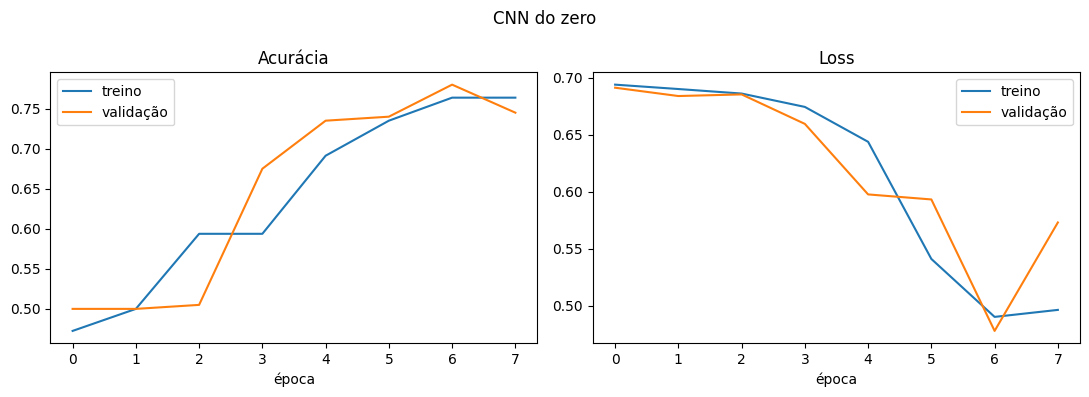

Modelo salvo em /Users/mario/Dropbox/FIAP/Ano2/Fiap-Ano2-CardioIA-Fase4-Cap1/models/cnn_scratch.keras


In [5]:
hist_scratch = cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_SCRATCH)
plotar_curvas(hist_scratch, 'CNN do zero', 'parte2_curvas_scratch.png')
cnn.save(config.MODEL_SCRATCH)
print('Modelo salvo em', config.MODEL_SCRATCH)

## Abordagem B — Transfer Learning (VGG16)

VGG16 pré-treinado no ImageNet, com a base **congelada** e uma cabeça nova.
A base é ligada via `input_tensor` (grafo plano), o que mantém o modelo
compatível com o Grad-CAM do app (acesso direto a `block5_conv3`).

In [6]:
def construir_transfer():
    inputs = tf.keras.Input(shape=(*config.IMG_SIZE, config.IMG_CHANNELS))
    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)
    base = tf.keras.applications.VGG16(
        weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False  # congela os pesos convolucionais
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs, name='cnn_transfer_vgg16')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

transfer = construir_transfer()
print('Camadas treináveis:', sum(1 for l in transfer.layers if l.trainable))
transfer.summary()

Camadas treináveis: 3


Model: "cnn_transfer_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5


 1/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4375 - loss: 1.0318

 2/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.4297 - loss: 1.0315

 3/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4392 - loss: 1.0141

 4/25 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.4486 - loss: 0.9956

...

22/25 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7027 - loss: 0.6014

23/25 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7023 - loss: 0.6015

24/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.7021 - loss: 0.6015

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7020 - loss: 0.6014

25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6988 - loss: 0.6004 - val_accuracy: 0.8450 - val_loss: 0.5643


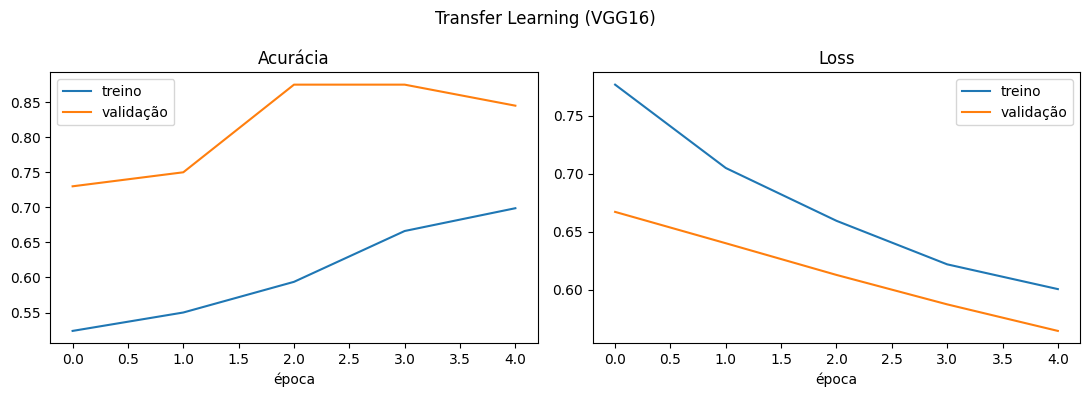

Modelo salvo em /Users/mario/Dropbox/FIAP/Ano2/Fiap-Ano2-CardioIA-Fase4-Cap1/models/cnn_transfer_vgg16.keras


In [7]:
hist_transfer = transfer.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_TRANSFER)
plotar_curvas(hist_transfer, 'Transfer Learning (VGG16)', 'parte2_curvas_transfer.png')
transfer.save(config.MODEL_TRANSFER)
print('Modelo salvo em', config.MODEL_TRANSFER)

## Avaliação e comparação

Métricas no conjunto de **teste** (nunca visto no treino).


=== scratch ===
              precision    recall  f1-score   support

      NORMAL       0.66      1.00      0.79       100
   PNEUMONIA       1.00      0.48      0.65       100

    accuracy                           0.74       200
   macro avg       0.83      0.74      0.72       200
weighted avg       0.83      0.74      0.72       200



2026-06-16 20:00:28.217197: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


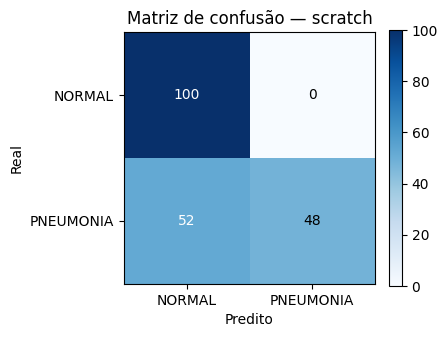


=== transfer ===
              precision    recall  f1-score   support

      NORMAL       0.80      0.95      0.87       100
   PNEUMONIA       0.94      0.76      0.84       100

    accuracy                           0.85       200
   macro avg       0.87      0.85      0.85       200
weighted avg       0.87      0.85      0.85       200



2026-06-16 20:00:39.746404: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


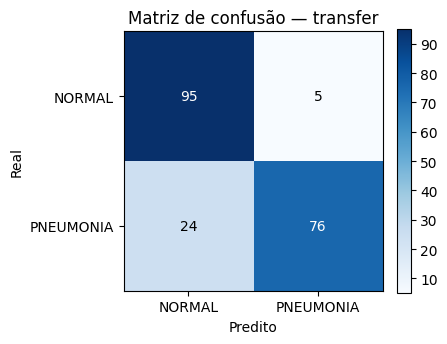

In [8]:
resultados = [
    avaliar(cnn, test_ds, 'scratch'),
    avaliar(transfer, test_ds, 'transfer'),
]

          acuracia  precisao  recall     f1
modelo                                     
scratch      0.740     1.000    0.48  0.649
transfer     0.855     0.938    0.76  0.840


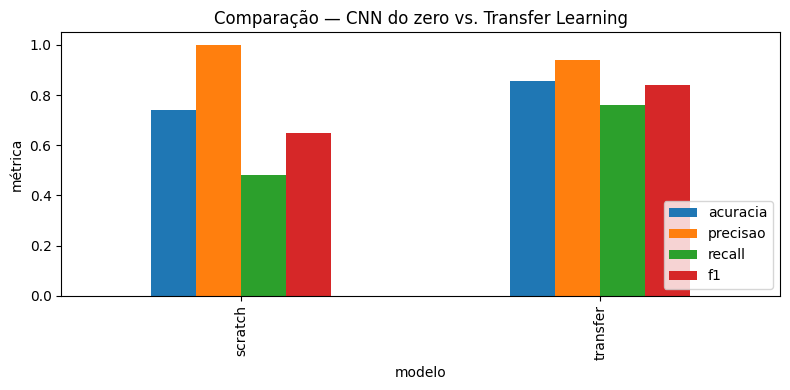

In [9]:
import pandas as pd

tabela = pd.DataFrame(resultados).set_index('modelo').round(3)
print(tabela)

ax = tabela.plot(kind='bar', figsize=(8, 4), ylim=(0, 1.05))
ax.set_title('Comparação — CNN do zero vs. Transfer Learning')
ax.set_ylabel('métrica'); ax.legend(loc='lower right')
ax.figure.tight_layout()
ax.figure.savefig(config.DOCS_DIR / 'parte2_comparacao.png', dpi=120)
plt.show()

### Conclusão da Parte 2

O Transfer Learning (VGG16) tende a superar a CNN do zero neste subset reduzido,
por reaproveitar bordas e texturas já aprendidas no ImageNet. Ambos os modelos
ficam salvos em `models/` e alimentam o **protótipo Flask** (`make web`), onde a
predição é apresentada com mapa de calor Grad-CAM. A análise completa está em
`docs/RELATORIO_PARTE2.md`.